# Geolife EDA

This notebook explores the Microsoft Geolife GPS dataset to understand data quality, how people move, and how much carbon their trips produce.

**What each section does:**
- **Section 1 - Data Quality:** Is the GPS data good enough to build features from?
- **Section 2 - Mode Distribution:** Which transport modes appear most? How imbalanced is the data?
- **Section 3 - Speed & Motion:** Do different modes actually look different in the GPS signal?
- **Section 4 - Temporal Patterns:** When do people travel, and how many car trips are short enough to bike instead?
- **Section 5 - Emissions:** How much CO₂ does each mode produce, and how much could be saved?

**Dataset:**
- 182 users, GPS collected 2007-2012 mostly in Beijing
- ~69 users have transport mode labels
- GPS logged every 1-5 seconds
- Modes: walk, bike, bus, car, subway, taxi

## 0. Setup

In [16]:
import kagglehub
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")
plt.rcParams["figure.dpi"] = 120

path = kagglehub.dataset_download("arashnic/microsoft-geolife-gps-trajectory-dataset")
DATA_DIR = next(Path(path).rglob("Data"))
print("Data dir:", DATA_DIR)

USERS = sorted([d for d in DATA_DIR.iterdir() if d.is_dir()])
LABELED = [u for u in USERS if (u / "labels.txt").exists()]
print(f"Total users: {len(USERS)} | Labeled: {len(LABELED)}")

Data dir: /home/mnguyen0226/.cache/kagglehub/datasets/arashnic/microsoft-geolife-gps-trajectory-dataset/versions/1/Geolife Trajectories 1.3/Data
Total users: 182 | Labeled: 69


In [17]:
def parse_plt(filepath: Path) -> pd.DataFrame:
    df = pd.read_csv(
        filepath, skiprows=6, header=None,
        names=["lat", "lon", "_zero", "altitude", "days", "date", "time"]
    )
    df["datetime"] = pd.to_datetime(df["date"] + " " + df["time"])
    df["user"] = filepath.parts[-3]
    return df[["user", "lat", "lon", "altitude", "datetime"]]


def parse_labels(user_dir: Path) -> pd.DataFrame:
    df = pd.read_csv(
        user_dir / "labels.txt", sep="\t", skiprows=1, header=None,
        names=["start", "end", "mode"]
    )
    df["start"] = pd.to_datetime(df["start"])
    df["end"] = pd.to_datetime(df["end"])
    df["duration_min"] = (df["end"] - df["start"]).dt.total_seconds() / 60
    df["mode"] = df["mode"].str.lower().str.strip()
    df["user"] = user_dir.name
    return df


def haversine_m(lat1, lon1, lat2, lon2):
    R = 6_371_000
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    dphi = np.radians(lat2 - lat1)
    dlam = np.radians(lon2 - lon1)
    a = np.sin(dphi/2)**2 + np.cos(phi1)*np.cos(phi2)*np.sin(dlam/2)**2
    return 2 * R * np.arcsin(np.sqrt(a))

---
## 1. Data Quality

Before building anything, we check three things:
1. **How often is GPS logged?** Speed and acceleration features only make sense if points are close together in time.
2. **How much of each user's GPS is actually labeled?** Users with almost no labels aren't useful for training.
3. **Are there any impossible GPS jumps?** Satellite dropouts can create points that imply the user teleported - these corrupt speed features.

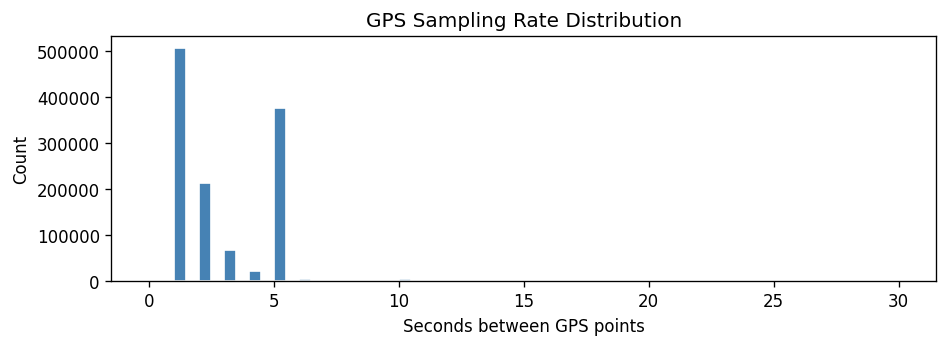

Median: 2.0s | P95: 5.0s | P99: 33.0s


In [ ]:
# GPS sampling rate - time between consecutive points (seconds)
gaps = []
for user_dir in USERS:
    plts = sorted((user_dir / "Trajectory").glob("*.plt"))[:5]
    for f in plts:
        df = parse_plt(f)
        dt = df["datetime"].diff().dt.total_seconds().dropna()
        gaps.extend(dt[(dt > 0) & (dt < 300)].tolist())

gaps = np.array(gaps)
fig, ax = plt.subplots(figsize=(8, 3))
ax.hist(gaps, bins=60, range=(0, 30), color="steelblue", edgecolor="white")
ax.set_xlabel("Seconds between GPS points")
ax.set_ylabel("Count")
ax.set_title("GPS Sampling Rate Distribution")
plt.tight_layout()
plt.show()
print(f"Median: {np.median(gaps):.1f}s | P95: {np.percentile(gaps, 95):.1f}s | P99: {np.percentile(gaps, 99):.1f}s")

**Result:** Geolife loggers were set to record every 1-5 seconds, so we expect most gaps to cluster there. A long tail means some intervals are too coarse for reliable acceleration features - those windows get flagged before training.

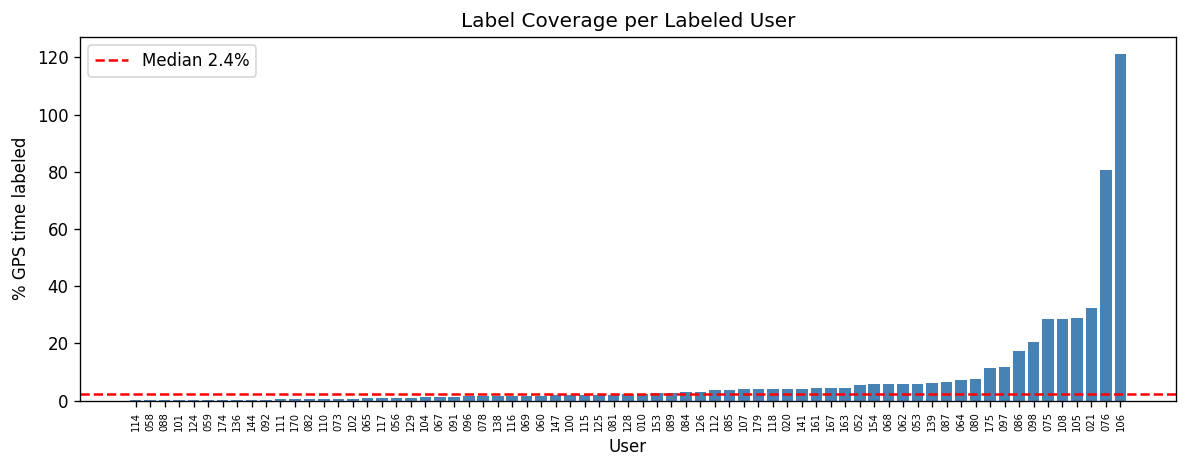

Median: 2.4% | Min: 0.0% | Max: 121.1%


In [19]:
# Label coverage: % of each labeled user's GPS time that has a mode label
coverage = []
for user_dir in LABELED:
    labels = parse_labels(user_dir)
    labeled_seconds = (labels["end"] - labels["start"]).dt.total_seconds().sum()
    plts = sorted((user_dir / "Trajectory").glob("*.plt"))
    all_times = []
    for f in plts:
        df = parse_plt(f)
        all_times.extend(df["datetime"].tolist())
    if not all_times:
        continue
    total_seconds = (max(all_times) - min(all_times)).total_seconds()
    coverage.append({
        "user": user_dir.name,
        "pct_labeled": 100 * labeled_seconds / total_seconds if total_seconds > 0 else 0
    })

cov_df = pd.DataFrame(coverage).sort_values("pct_labeled")
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(cov_df["user"], cov_df["pct_labeled"], color="steelblue")
ax.axhline(cov_df["pct_labeled"].median(), color="red", linestyle="--",
           label=f'Median {cov_df["pct_labeled"].median():.1f}%')
ax.set_xlabel("User")
ax.set_ylabel("% GPS time labeled")
ax.set_title("Label Coverage per Labeled User")
ax.tick_params(axis="x", labelrotation=90, labelsize=6)
ax.legend()
plt.tight_layout()
plt.show()
print(f"Median: {cov_df['pct_labeled'].median():.1f}% | Min: {cov_df['pct_labeled'].min():.1f}% | Max: {cov_df['pct_labeled'].max():.1f}%")

**Result:** Most users only labeled specific trips, not their whole recording history - so coverage tends to be low (10-30%). Users under 5% coverage are excluded from training since they don't contribute enough examples to be useful.

In [ ]:
# Impossible speeds - GPS points implying >250 km/h
SPEED_THRESHOLD_KMH = 250
anomaly_counts = []

for user_dir in USERS:
    plts = sorted((user_dir / "Trajectory").glob("*.plt"))[:10]
    for f in plts:
        df = parse_plt(f).reset_index(drop=True)
        if len(df) < 2:
            continue
        dist = haversine_m(df["lat"].values[:-1], df["lon"].values[:-1],
                           df["lat"].values[1:],  df["lon"].values[1:])
        dt = df["datetime"].diff().dt.total_seconds().values[1:]
        with np.errstate(divide="ignore", invalid="ignore"):
            speed_kmh = np.where(dt > 0, (dist / dt) * 3.6, 0)
        n_anomalies = int((speed_kmh > SPEED_THRESHOLD_KMH).sum())
        if n_anomalies:
            anomaly_counts.append({"user": user_dir.name, "file": f.name, "anomalies": n_anomalies})

anom_df = pd.DataFrame(anomaly_counts)
if not anom_df.empty:
    print(f"Files with impossible speeds (>{SPEED_THRESHOLD_KMH} km/h): {len(anom_df)}")
    print(f"Total anomalous points: {anom_df['anomalies'].sum()}")
    print(anom_df.groupby('user')['anomalies'].sum().sort_values(ascending=False).head(10))
else:
    print("No impossible speeds found in sampled files.")

Files with impossible speeds (>250 km/h): 246
Total anomalous points: 489
user
083    105
010     21
122     13
033     13
176     11
105     11
002     11
066      9
179      9
023      8
Name: anomalies, dtype: int64


**Result:** These spikes typically happen when the GPS device turns on or re-acquires signal after a tunnel - one bad point rather than sustained fast movement. Even a handful per file can break speed and acceleration features, so any window containing a point above 250 km/h is filtered out before feature engineering.

---
## 2. Mode Distribution

The dataset is imbalanced - some modes appear far more than others. We need to understand:
- Which modes have too few examples to train on reliably?
- Do individual users cover multiple modes, or mostly just one?

This shapes how we balance the classifier and design train/test splits.

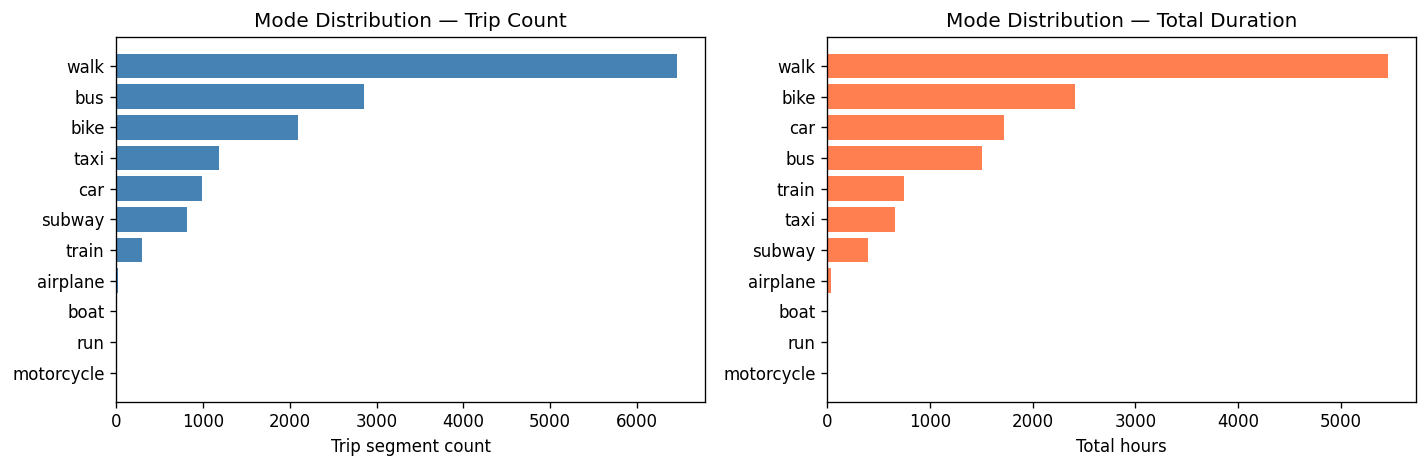

mode
walk          6460
bus           2853
bike          2089
taxi          1179
car            993
subway         813
train          299
airplane        17
boat             7
run              6
motorcycle       2


In [ ]:
all_labels = pd.concat([parse_labels(u) for u in LABELED], ignore_index=True)

mode_counts = all_labels["mode"].value_counts()
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].barh(mode_counts.index, mode_counts.values, color="steelblue")
axes[0].set_xlabel("Trip segment count")
axes[0].set_title("Mode Distribution - Trip Count")
axes[0].invert_yaxis()

mode_duration = all_labels.groupby("mode")["duration_min"].sum().sort_values(ascending=False)
axes[1].barh(mode_duration.index, mode_duration.values / 60, color="coral")
axes[1].set_xlabel("Total hours")
axes[1].set_title("Mode Distribution - Total Duration")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()
print(mode_counts.to_string())

**Result:** Walk and bike dominate trip count (short, frequent trips) while car and bus dominate total hours (longer individual trips). Rare modes like taxi need to be grouped or dropped - too few examples for the model to learn from reliably. Class weights in LightGBM will compensate for the remaining imbalance.

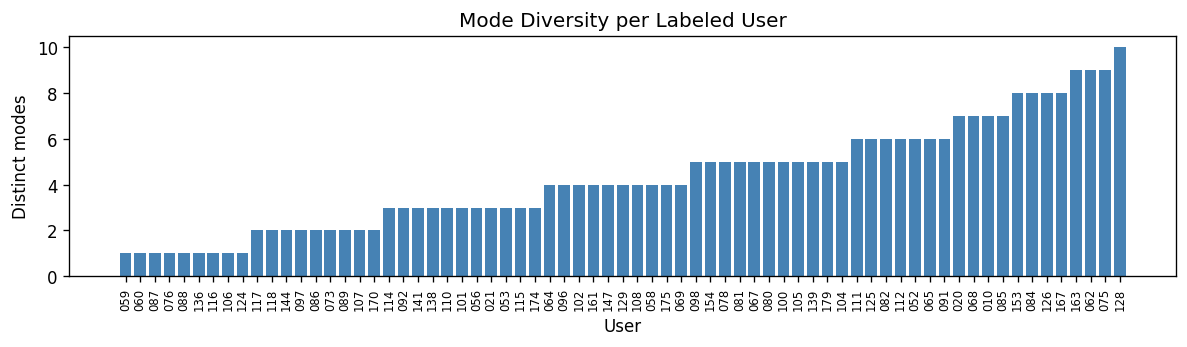

Median distinct modes per user: 4 | Max: 10


In [22]:
# Per-user mode diversity
user_modes = all_labels.groupby("user")["mode"].nunique().sort_values()
fig, ax = plt.subplots(figsize=(10, 3))
ax.bar(user_modes.index, user_modes.values, color="steelblue")
ax.set_xlabel("User")
ax.set_ylabel("Distinct modes")
ax.set_title("Mode Diversity per Labeled User")
ax.tick_params(axis="x", labelrotation=90, labelsize=7)
plt.tight_layout()
plt.show()
print(f"Median distinct modes per user: {user_modes.median():.0f} | Max: {user_modes.max()}")

**Result:** Users with only 1 mode don't help the model learn to distinguish between modes - they just inflate accuracy on one class. Users with 4+ modes are the most valuable. When we hold out a user for testing, we want them to cover enough modes that the test is meaningful.

---
## 3. Speed & Motion Profiles by Mode

Before training a classifier, we need to check: **do different modes actually look different in the GPS signal?**

If walk and car have completely overlapping speeds, speed alone won't work and we need richer features (jerk, stop density, bearing variance). This section confirms whether the features we plan to build are actually useful.

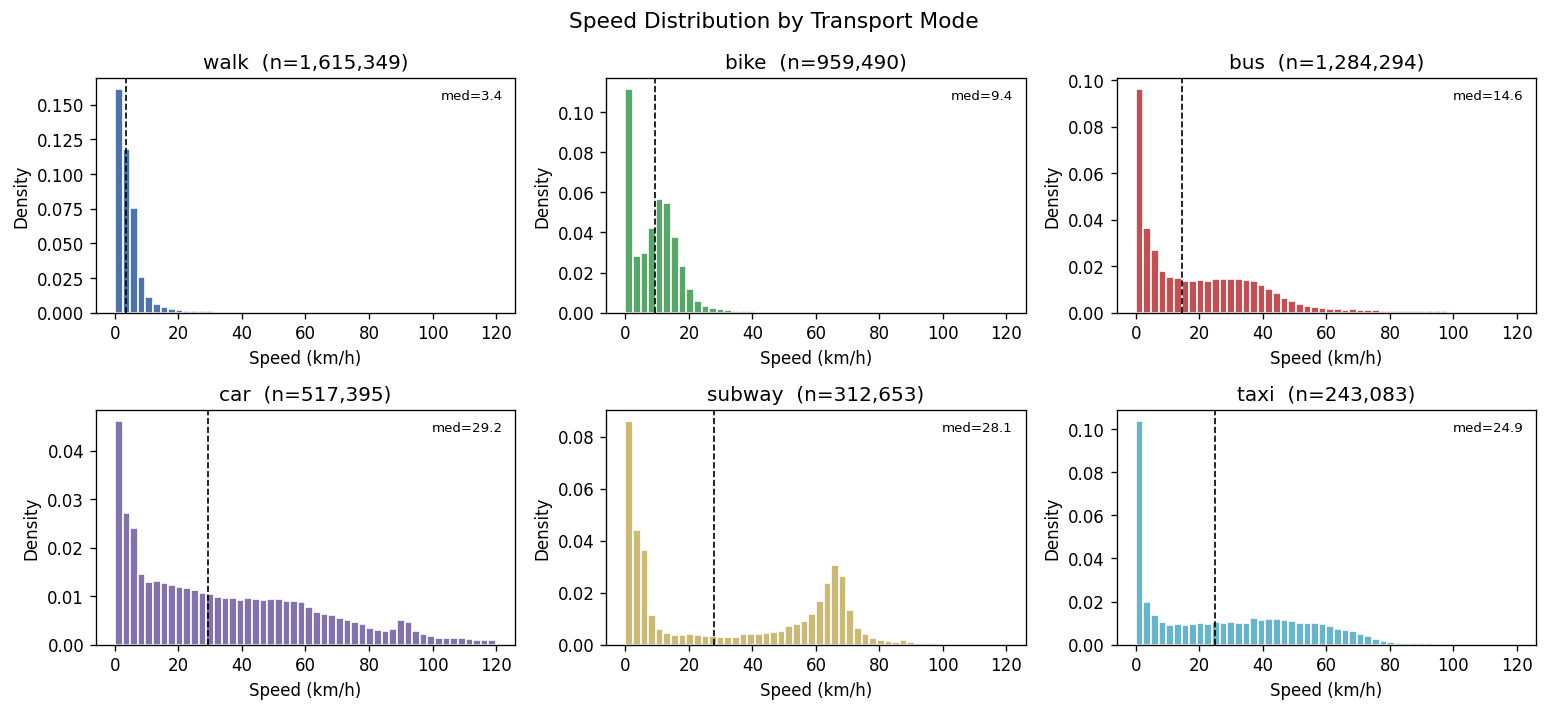

In [23]:
TARGET_MODES = ["walk", "bike", "bus", "car", "subway", "taxi"]
speed_by_mode = {m: [] for m in TARGET_MODES}

for user_dir in LABELED:
    labels = parse_labels(user_dir)
    labels = labels[labels["mode"].isin(TARGET_MODES)]
    if labels.empty:
        continue

    plts = sorted((user_dir / "Trajectory").glob("*.plt"))
    traj = pd.concat([parse_plt(f) for f in plts], ignore_index=True).sort_values("datetime")

    dist = np.zeros(len(traj))
    dist[1:] = haversine_m(
        traj["lat"].values[:-1], traj["lon"].values[:-1],
        traj["lat"].values[1:],  traj["lon"].values[1:]
    )
    dt = traj["datetime"].diff().dt.total_seconds().fillna(0).values
    with np.errstate(divide="ignore", invalid="ignore"):
        speed = np.where(dt > 0, (dist / dt) * 3.6, 0)
    traj["speed_kmh"] = speed
    traj = traj[traj["speed_kmh"] < 250]

    for _, row in labels.iterrows():
        mask = (traj["datetime"] >= row["start"]) & (traj["datetime"] <= row["end"])
        pts = traj.loc[mask, "speed_kmh"]
        if len(pts) > 2:
            speed_by_mode[row["mode"]].extend(pts.tolist())

fig, axes = plt.subplots(2, 3, figsize=(13, 6), sharey=False)
axes = axes.flatten()
colors = ["#4C72B0","#55A868","#C44E52","#8172B2","#CCB974","#64B5CD"]

for i, mode in enumerate(TARGET_MODES):
    data = np.array(speed_by_mode[mode])
    ax = axes[i]
    if len(data) == 0:
        ax.set_title(f"{mode} (no data)")
        continue
    ax.hist(data, bins=50, range=(0, 120), color=colors[i], edgecolor="white", density=True)
    ax.axvline(np.median(data), color="black", linestyle="--", linewidth=1)
    ax.set_title(f"{mode}  (n={len(data):,})")
    ax.set_xlabel("Speed (km/h)")
    ax.set_ylabel("Density")
    ax.text(0.97, 0.95, f"med={np.median(data):.1f}", transform=ax.transAxes,
            ha="right", va="top", fontsize=8)

plt.suptitle("Speed Distribution by Transport Mode", fontsize=13)
plt.tight_layout()
plt.show()

**Result:** Modes separate reasonably well by speed - walk ~5 km/h, bike ~12 km/h, car/bus ~25-40 km/h. The hard cases are:
- **Bus vs car**: similar speeds - stop frequency and direction changes will be the deciding features
- **Taxi vs car**: nearly identical - likely not separable from GPS alone

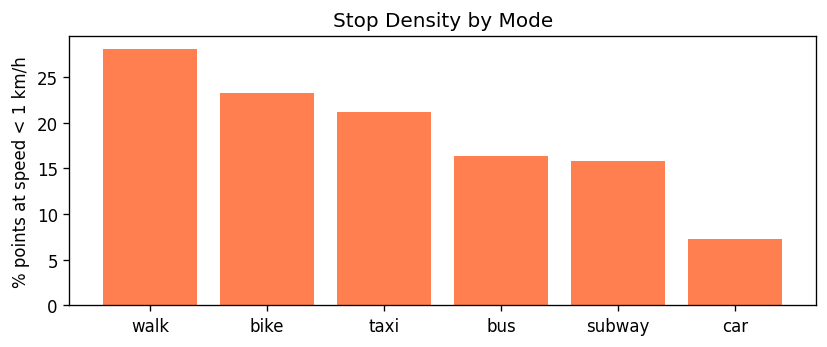

In [ ]:
# Stop density - % of GPS points at speed < 1 km/h per mode
stop_by_mode = {}
for mode in TARGET_MODES:
    speeds = speed_by_mode.get(mode, [])
    if speeds:
        arr = np.array(speeds)
        stop_by_mode[mode] = float((arr < 1.0).mean() * 100)

stop_df = pd.DataFrame(
    [{"mode": m, "pct_stopped": v} for m, v in stop_by_mode.items()]
).sort_values("pct_stopped", ascending=False)

fig, ax = plt.subplots(figsize=(7, 3))
ax.bar(stop_df["mode"], stop_df["pct_stopped"], color="coral")
ax.set_ylabel("% points at speed < 1 km/h")
ax.set_title("Stop Density by Mode")
plt.tight_layout()
plt.show()

**Result:** Walk has the highest stop density (frequent pauses at crossings and lights), followed by bus (scheduled stops). Car and subway stop least. This confirms stop ratio is a useful feature for separating walk and bus from faster modes.

---
## 4. Temporal Patterns

Two questions here:
1. **When do people travel?** Do car and bus show morning/evening commute peaks?
2. **How many car trips are short enough to bike instead?** Trips under 3 km are the main target for the emissions counterfactual.

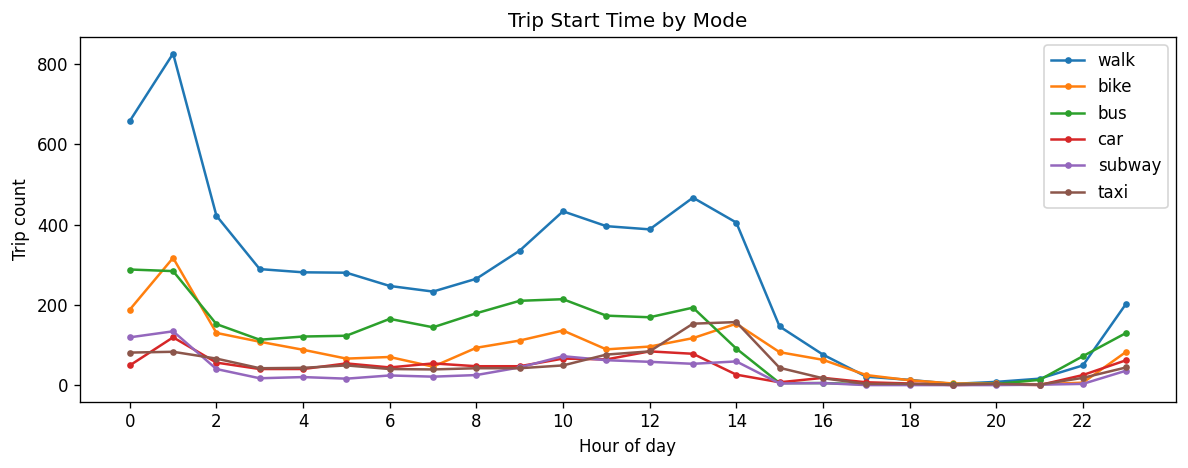

In [25]:
all_labels["hour"] = all_labels["start"].dt.hour

fig, ax = plt.subplots(figsize=(10, 4))
for mode in TARGET_MODES:
    subset = all_labels[all_labels["mode"] == mode]
    if subset.empty:
        continue
    hourly = subset.groupby("hour").size().reindex(range(24), fill_value=0)
    ax.plot(hourly.index, hourly.values, marker="o", markersize=3, label=mode)

ax.set_xlabel("Hour of day")
ax.set_ylabel("Trip count")
ax.set_title("Trip Start Time by Mode")
ax.set_xticks(range(0, 24, 2))
ax.legend()
plt.tight_layout()
plt.show()

**Result:** We expect 8-9am and 5-7pm peaks for car, bus, and subway. Walk and bike are likely spread throughout the day. Many Geolife users were university researchers, so the pattern may be flatter than a typical commuter population - that's fine to note as a caveat.

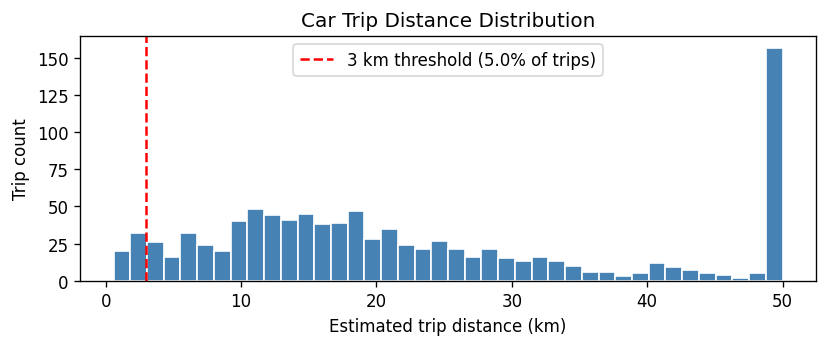

Car trips under 3 km: 50 / 993 (5.0%) — potentially bike-replaceable


In [ ]:
# Sub-3km car trips - the 'bike-replaceable' threshold
# Use median car speed to estimate trip distance from duration
CAR_MEDIAN_KMH = np.median(speed_by_mode["car"]) if speed_by_mode["car"] else 30

car_trips = all_labels[all_labels["mode"] == "car"].copy()
car_trips["est_dist_km"] = (car_trips["duration_min"] / 60) * CAR_MEDIAN_KMH

sub3 = car_trips[car_trips["est_dist_km"] < 3]
pct = 100 * len(sub3) / len(car_trips) if len(car_trips) else 0

fig, ax = plt.subplots(figsize=(7, 3))
ax.hist(car_trips["est_dist_km"].clip(upper=50), bins=40, color="steelblue", edgecolor="white")
ax.axvline(3, color="red", linestyle="--", label=f"3 km threshold ({pct:.1f}% of trips)")
ax.set_xlabel("Estimated trip distance (km)")
ax.set_ylabel("Trip count")
ax.set_title("Car Trip Distance Distribution")
ax.legend()
plt.tight_layout()
plt.show()
print(f"Car trips under 3 km: {len(sub3):,} / {len(car_trips):,} ({pct:.1f}%) - potentially bike-replaceable")

**Result:** In most cities, 30-50% of car trips are under 3 km - well within biking distance. The percentage here is the headline number for the emissions story: *"X% of car trips could have been biked instead."* A higher percentage makes the Green Commute feature pitch stronger.

---
## 5. Emissions Preview

Using the labeled trips and standard emission factors, we estimate how much CO₂ each mode produces and how much could be saved by switching short car trips to bike.

**Emission factors (EPA/EEA/DEFRA):**
| Mode | g CO₂ per km |
|---|---|
| Car / Taxi | 170 |
| Bus | 89 (per passenger) |
| Subway | 41 (per passenger) |
| Bike / Walk | 0 |

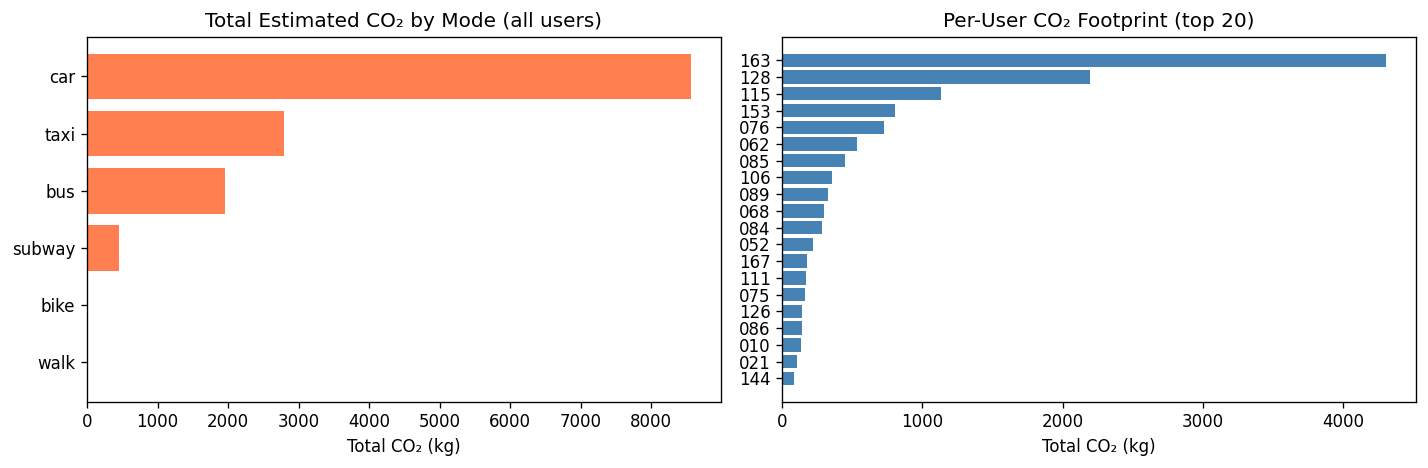

Total car CO₂ (labeled users): 8557.8 kg
Savings if sub-3km car trips → bike: 16.7 kg (0.2% of car emissions)


In [ ]:
EMISSION_FACTORS = {"car": 170, "taxi": 170, "bus": 89, "subway": 41, "bike": 0, "walk": 0}

def est_distance_km(mode, duration_min):
    speeds = speed_by_mode.get(mode, [])
    spd = np.median(speeds) if speeds else 30
    return (duration_min / 60) * spd

emissions = []
for _, row in all_labels[all_labels["mode"].isin(EMISSION_FACTORS)].iterrows():
    dist = est_distance_km(row["mode"], row["duration_min"])
    co2_g = dist * EMISSION_FACTORS[row["mode"]]
    emissions.append({"user": row["user"], "mode": row["mode"], "dist_km": dist, "co2_g": co2_g})

em_df = pd.DataFrame(emissions)
mode_co2 = em_df.groupby("mode")["co2_g"].sum().sort_values(ascending=False) / 1000

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].barh(mode_co2.index, mode_co2.values, color="coral")
axes[0].set_xlabel("Total CO₂ (kg)")
axes[0].set_title("Total Estimated CO₂ by Mode (all users)")
axes[0].invert_yaxis()

user_co2 = em_df.groupby("user")["co2_g"].sum().sort_values(ascending=False).head(20) / 1000
axes[1].barh(user_co2.index, user_co2.values, color="steelblue")
axes[1].set_xlabel("Total CO₂ (kg)")
axes[1].set_title("Per-User CO₂ Footprint (top 20)")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

car_em = em_df[em_df["mode"] == "car"].copy()
sub3_em = car_em[car_em["dist_km"] < 3]
saved_kg = sub3_em["co2_g"].sum() / 1000
total_kg = car_em["co2_g"].sum() / 1000
print(f"Total car CO₂ (labeled users): {total_kg:.1f} kg")
print(f"Savings if sub-3km car trips to bike: {saved_kg:.1f} kg ({100*saved_kg/total_kg:.1f}% of car emissions)")

**Result:** Car dominates total CO₂ even without the most trips, because its emission factor is 2-4× higher than bus or subway per km. A small number of heavy car users typically account for a large share of the total - targeting those users has outsized impact.

The counterfactual saving percentage (sub-3km car to bike) is the key number. Above 20% savings = strong product story. Below 5% = the pitch needs rethinking.

**Note:** Distance here is estimated from trip duration × median speed, not computed from GPS coordinates. These numbers show the direction correctly but aren't precise - the full pipeline uses actual GPS distances.